## Seasonality

In [1]:
import xarray as xr
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.patches as mpatches
from tqdm import tqdm

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
from dask.distributed import Client
client = Client(n_workers=4, threads_per_worker=3, memory_limit=15e9)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 12,Total memory: 55.88 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35069,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39983,Total threads: 3
Dashboard: http://127.0.0.1:37175/status,Memory: 13.97 GiB
Nanny: tcp://127.0.0.1:39095,


In [4]:
!echo dask dashboard :D
!echo https://jupyterhub.dkrz.de/user/$USER/levante-spawner-preset/proxy/8787/status

dask dashboard :D
https://jupyterhub.dkrz.de/user/b383184/levante-spawner-preset/proxy/8787/status


In [5]:
ssh = xr.open_dataset('/work/bk1450/b383184/Amazon/Mercator/data/variables_c/tracers/SSH_1993-01c.nc')
ssh = ssh.compute()

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'sossheig' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


In [6]:
uu = xr.open_dataset('/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/U_1993-01c.nc').deptht
uu

<xarray.DataArray 'deptht' (deptht: 50)> Size: 200B
array([4.940254e-01, 1.541375e+00, 2.645669e+00, 3.819495e+00, 5.078224e+00,
       6.440614e+00, 7.929560e+00, 9.572997e+00, 1.140500e+01, 1.346714e+01,
       1.581007e+01, 1.849556e+01, 2.159882e+01, 2.521141e+01, 2.944473e+01,
       3.443415e+01, 4.034405e+01, 4.737369e+01, 5.576429e+01, 6.580727e+01,
       7.785385e+01, 9.232607e+01, 1.097293e+02, 1.306660e+02, 1.558507e+02,
       1.861256e+02, 2.224752e+02, 2.660403e+02, 3.181274e+02, 3.802130e+02,
       4.539377e+02, 5.410889e+02, 6.435668e+02, 7.633331e+02, 9.023393e+02,
       1.062440e+03, 1.245291e+03, 1.452251e+03, 1.684284e+03, 1.941893e+03,
       2.225078e+03, 2.533336e+03, 2.865703e+03, 3.220820e+03, 3.597032e+03,
       3.992484e+03, 4.405224e+03, 4.833291e+03, 5.274784e+03, 5.727917e+03],
      dtype=float32)
Coordinates:
  * deptht   (deptht) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
Attributes:
    standard_name:  depth
    long_name:      Vertical T levels
    units:          m
    positive:       down
    axis:           Z
    _ChunkSizes:    50

In [7]:
dz = np.diff(uu['deptht'].values, prepend=0)
dz = xr.DataArray(dz, dims='deptht', coords={'deptht': uu['deptht']})
dz = dz.rename({'deptht':'depth'})
dz

<xarray.DataArray (depth: 50)> Size: 400B
array([  0.49402538,   1.04735002,   1.10429311,   1.17382622,
         1.25872898,   1.36239052,   1.48894596,   1.64343691,
         1.8320055 ,   2.0621357 ,   2.34293461,   2.68548679,
         3.10325623,   3.6125927 ,   4.23332024,   4.98942566,
         5.90989685,   7.02963638,   8.39060211,  10.04298401,
        12.04657745,  14.47222137,  17.40320587,  20.93670654,
        25.18473816,  30.27484131,  36.34960938,  43.56507874,
        52.08718872,  62.08557129,  73.72473145,  87.15118408,
       102.47790527, 119.76623535, 139.00622559, 160.10040283,
       182.85144043, 206.95983887, 232.03344727, 257.60900879,
       283.18444824, 308.25830078, 332.36645508, 355.11767578,
       376.21166992, 395.4519043 , 412.74023438, 428.06640625,
       441.49365234, 453.13232422])
Coordinates:
  * depth    (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03

In [8]:
# !mkdir RMS_dweighted

In [9]:
import glob

Ufiles = sorted(glob.glob('/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/U*.nc'))
print(len(Ufiles), Ufiles[:5], Ufiles[-5:])

Vfiles = sorted(glob.glob('/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/V*.nc'))
print(len(Vfiles), Vfiles[:5], Vfiles[-5:])

# # Peek at first two
# for f in Ufiles[:3]:
#     with xr.open_dataset(f) as ds:
#         print(f, ds['vozocrtx'].load().values[:3], ds['time_counter'].load().values[-3:])

262 ['/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/U_1993-01c.nc', '/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/U_1993-02c.nc', '/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/U_1993-03c.nc', '/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/U_1993-04c.nc', '/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/U_1993-05c.nc'] ['/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/U_2014-07c.nc', '/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/U_2014-09c.nc', '/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/U_2014-10c.nc', '/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/U_2014-11c.nc', '/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/U_2014-12c.nc']
262 ['/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/V_1993-01c.nc', '/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/V_1993-02c.nc', '/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/V_1993-03c.nc', '/work/bk1450/

In [12]:
for uf, vf in tqdm(zip(Ufiles, Vfiles, strict=True), total=len(Ufiles)):
    # print(uf, vf)
    # fn = f[-2:-12]
    
    ## Open the data 
    U = xr.open_dataset(uf, 
                         chunks={'time_counter':-1, 'deptht': 7, 'y': 250, 'x': 600},
                        ).isel(deptht=slice(0, 7))
    U = U.rename({"vozocrtx": "U"})

    V = xr.open_dataset(vf, 
                        chunks={'time_counter':-1, 'deptht': 7, 'y': 250, 'x': 600},
                       ).isel(deptht=slice(0, 7))
    
    V = V.rename({"vomecrty": "V"})
    
    # load the data
    U = U.load()
    V = V.load()

    # Interpolate to the centers
    U_T = (U.U.shift(x=1) + U.U)*0.5
    V_T = (V.V.shift(y=1) + V.V)*0.5

    # Dataset creation
    UV = xr.Dataset(
    data_vars={
        'U': (('time','depth','lat','lon'), U_T.data),
        'V': (('time','depth','lat', 'lon'), V_T.data),
    },
    coords={
        'time':U_T.time_counter.data,
        'depth':U_T.deptht.data,
        'lat':ssh.nav_lat.isel(x=0).data,
        'lon':ssh.nav_lon.isel(y=0).data,
    }
    )

    # Monthly RMS of Speed calculation 
    # rms_speed = (((UV.U**2 + UV.V**2).mean('time'))**0.5).mean('depth') 
    rms_speed_layer = ((UV.U**2 + UV.V**2).mean('time').weighted(dz).mean('depth'))**0.5
    # time dimension
    rms_speed = rms_speed_layer.expand_dims(time=[np.datetime64(str(uf[-11:-4]))])
    # To netcdf 
    rms_speed.to_dataset(name = 'RMS').to_netcdf('RMS_dweighted/RMS_'+str(uf[-11:-4])+'.nc')

100%|██████████| 262/262 [2:11:17<00:00, 30.07s/it]  


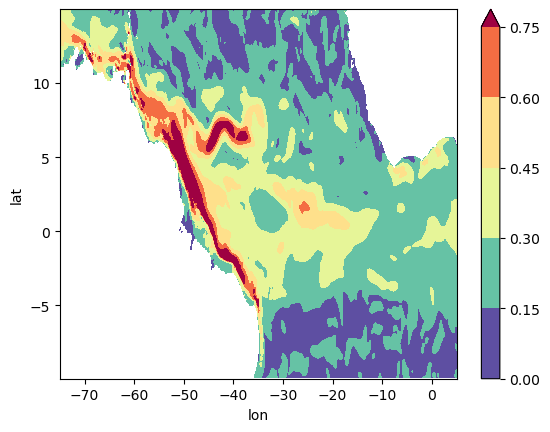

In [64]:
# rms_speed_layer = ((UV.U**2 + UV.V**2).mean('time').weighted(dz).mean('depth'))**0.5
# rms_speed_layer.sel(lon=slice(-75,5),lat=slice(-10,15)).plot.contourf(cmap='Spectral_r',robust=True)

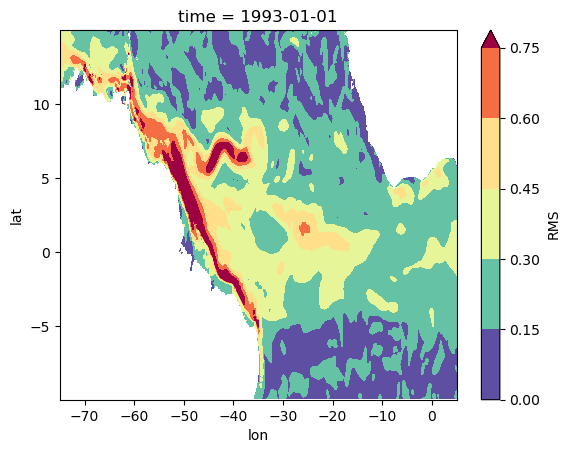

In [65]:
# ss = xr.open_dataset('RMS/RMS_1993-01.nc')
# ss = ss.compute()
# ss.RMS.isel(time=0).sel(lon=slice(-75,5),lat=slice(-10,15)).plot.contourf(cmap='Spectral_r',robust=True)

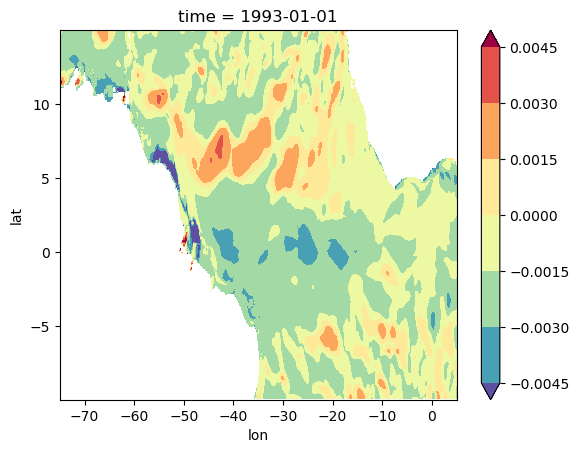

In [66]:
# (rms_speed_layer - ss.RMS.isel(time=0)).sel(lon=slice(-75,5),lat=slice(-10,15)).plot.contourf(cmap='Spectral_r',robust=True)

In [9]:
# UV = xr.Dataset(
#     data_vars={
#         'U': (('time','depth','lat','lon'), U_T.data),
#         'V': (('time','depth','lat', 'lon'), V_T.data),
#     },
#     coords={
#         'time':U_T.time_counter.data,
#         'depth':U_T.deptht.data,
#         'lat':ssh.nav_lat.isel(x=0).data,
#         'lon':ssh.nav_lon.isel(y=0).data,
#     }
# )
# UV

In [10]:
# UV.isel(time=0).load()
# rms_speed = (((UV.U**2 + UV.V**2).mean('time'))**0.5).mean('depth') 
# rms_speed.plot.contourf(robust=True)
# plt.title('RMS')

In [11]:
# rms_speed = rms_speed.expand_dims(time=[np.datetime64("1993-01")])


In [12]:
# print(uf)
# str(uf[-11:-4])

In [13]:
# rms_speed.to_dataset(name = 'RMS').to_netcdf('RMS_'+str(uf[-11:-4])+'.nc')

In [14]:
# ss = xr.open_mfdataset('RMS/RMS_*.nc')
# ss